In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import libraries
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Set project paths
PROJECT_DIR = "/content/drive/MyDrive/DLP2"

PROCESSED_DIR = os.path.join(PROJECT_DIR, "data/processed")
MODELS_DIR = os.path.join(PROJECT_DIR, "models")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
FIGURES_DIR = os.path.join(PROJECT_DIR, "figures")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

In [ ]:
# Load processed dataset
X_train = np.load(os.path.join(PROCESSED_DIR, "X_train.npy"))
X_val = np.load(os.path.join(PROCESSED_DIR, "X_val.npy"))
X_test = np.load(os.path.join(PROCESSED_DIR, "X_test.npy"))

y_train = np.load(os.path.join(PROCESSED_DIR, "y_train.npy"))
y_val = np.load(os.path.join(PROCESSED_DIR, "y_val.npy"))
y_test = np.load(os.path.join(PROCESSED_DIR, "y_test.npy"))

with open(os.path.join(PROCESSED_DIR, "activity_labels.json"), "r") as f:
    activity_labels = json.load(f)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

print(activity_labels)

X_train: (5881, 128, 9)
X_val: (1471, 128, 9)
X_test: (2947, 128, 9)
y_train: (5881,)
y_val: (1471,)
y_test: (2947,)
{'0': 'WALKING', '1': 'WALKING_UPSTAIRS', '2': 'WALKING_DOWNSTAIRS', '3': 'SITTING', '4': 'STANDING', '5': 'LAYING'}


In [ ]:
# Set basic constants
TIME_STEPS = X_train.shape[1]
NUM_CHANNELS = X_train.shape[2]
NUM_CLASSES = len(activity_labels)

INPUT_SHAPE = (TIME_STEPS, NUM_CHANNELS)

print("Input shape:", INPUT_SHAPE)
print("Number of classes:", NUM_CLASSES)

Input shape: (128, 9)
Number of classes: 6


In [ ]:

def build_cnn_gru_model(input_shape, num_classes):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv1D(
            filters=64,
            kernel_size=3,
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(
            filters=128,
            kernel_size=3,
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling1D(pool_size=2),

        layers.GRU(
            units=64,
            return_sequences=False
        ),

        layers.Dense(64, activation="relu"),

        layers.Dense(num_classes, activation="softmax")
    ])

    return model


cnn_gru_model = build_cnn_gru_model(INPUT_SHAPE, NUM_CLASSES)

cnn_gru_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 128, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,294 (266.77 KB)

 Trainable params: 68,294 (266.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
cnn_gru_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Add callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

model_checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(MODELS_DIR, "cnn_gru_best.keras"),
    monitor="val_loss",
    save_best_only=True
)

In [ ]:
# Train the model
history = cnn_gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.7575 - loss: 0.6369 - val_accuracy: 0.9320 - val_loss: 0.1813
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9451 - loss: 0.1458 - val_accuracy: 0.9490 - val_loss: 0.1177
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9497 - loss: 0.1186 - val_accuracy: 0.9490 - val_loss: 0.1055
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9500 - loss: 0.1101 - val_accuracy: 0.9538 - val_loss: 0.1079
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9509 - loss: 0.1067 - val_accuracy: 0.9558 - val_loss: 0.0988
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9537 - loss: 0.1011 - val_accuracy: 0.9640 - val_loss: 0.0959
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9468 - loss: 0.1210 - val_accuracy: 0.9531 - val_loss: 0.1035
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9549 - loss: 0.0966 - val_accuracy: 0.9660 - v

In [ ]:
# Evaluate on test set
test_loss, test_accuracy = cnn_gru_model.evaluate(X_test, y_test, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.34465959668159485
Test Accuracy: 0.9338310360908508


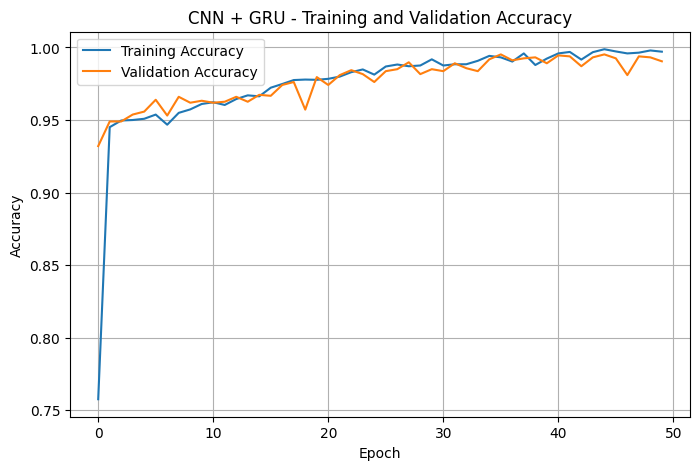

In [ ]:
# Plot accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN + GRU - Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(FIGURES_DIR, "cnn_gru_accuracy.png"), dpi=300, bbox_inches="tight")
plt.show()

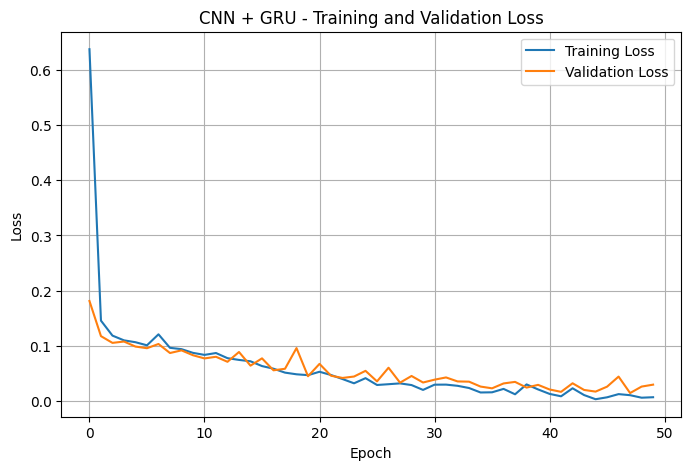

In [ ]:
# Plot loss curve
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN + GRU - Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(FIGURES_DIR, "cnn_gru_loss.png"), dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Generate predictions
y_pred_probs = cnn_gru_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [ ]:
# Classification report
target_names = [activity_labels[str(i)] for i in range(NUM_CLASSES)]

report = classification_report(
    y_test,
    y_pred,
    target_names=target_names,
    digits=4
)

print(report)

                    precision    recall  f1-score   support

           WALKING     0.9934    0.9113    0.9506       496
  WALKING_UPSTAIRS     0.9591    0.9448    0.9519       471
WALKING_DOWNSTAIRS     0.8856    0.9952    0.9372       420
           SITTING     0.9243    0.8208    0.8695       491
          STANDING     0.8614    0.9342    0.8963       532
            LAYING     0.9890    1.0000    0.9944       537

          accuracy                         0.9338      2947
         macro avg     0.9354    0.9344    0.9333      2947
      weighted avg     0.9364    0.9338    0.9336      2947



In [ ]:
with open(os.path.join(RESULTS_DIR, "cnn_gru_classification_report.txt"), "w") as f:
    f.write(report)

print("Classification report saved.")

Classification report saved.


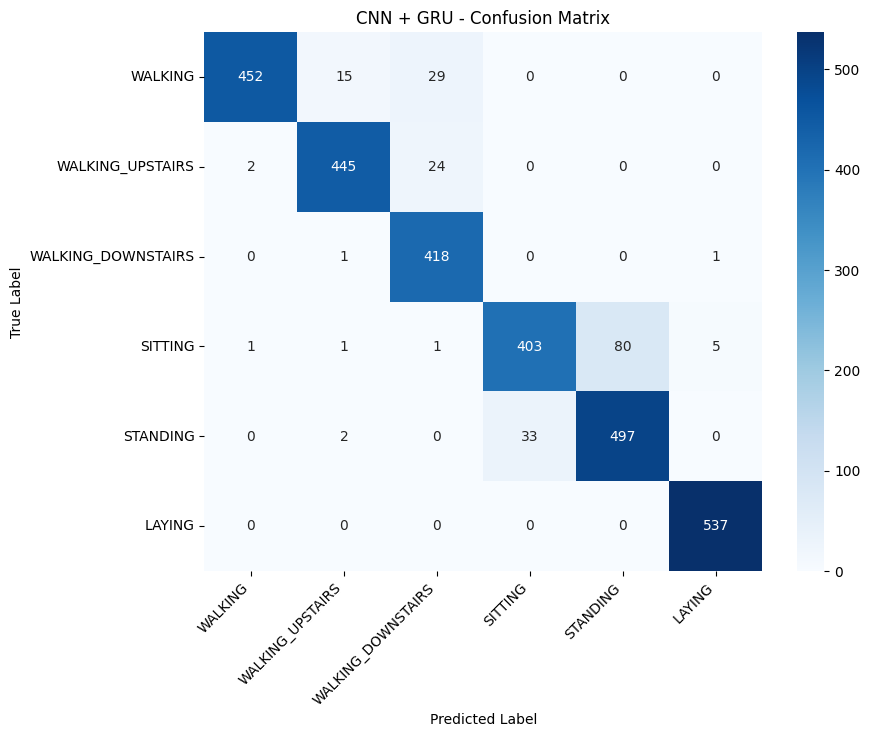

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=target_names,
    yticklabels=target_names,
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN + GRU - Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.savefig(os.path.join(FIGURES_DIR, "cnn_gru_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Save final model
cnn_gru_model.save(os.path.join(MODELS_DIR, "cnn_gru_final.keras"))

print("CNN + GRU model saved.")

CNN + GRU model saved.


In [ ]:
# Save summary results as JSON
cnn_gru_results = {
    "experiment": "Experiment 2 - CNN + GRU",
    "model": "Conv1D + MaxPooling1D + GRU + Dense",
    "input_shape": list(INPUT_SHAPE),
    "num_classes": NUM_CLASSES,
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "batch_size": 64,
    "gru_units": 64,
    "epochs_trained": len(history.history["loss"]),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "total_parameters": cnn_gru_model.count_params()
}

with open(os.path.join(RESULTS_DIR, "cnn_gru_results.json"), "w") as f:
    json.dump(cnn_gru_results, f, indent=4)

cnn_gru_results

{'experiment': 'Experiment 2 - CNN + GRU',
 'model': 'Conv1D + MaxPooling1D + GRU + Dense',
 'input_shape': [128, 9],
 'num_classes': 6,
 'optimizer': 'Adam',
 'learning_rate': 0.001,
 'batch_size': 64,
 'gru_units': 64,
 'epochs_trained': 50,
 'test_loss': 0.34465959668159485,
 'test_accuracy': 0.9338310360908508,
 'total_parameters': 68294}